In [1]:
!pip install pandas astroquery astropy numpy matplotlib scipy

In [34]:
import sys
sys.path.append('../gaiadr3_analysis')

import gaia_input as gi
import mean_photometry as mphot
import epoch_photometry as ephot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [ ]:
df = gi.get_dataframe()
"""
SELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )
"""


1. ADQL query
2. CSV file


In [4]:
source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

Retrieved 31 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,4371780385208211584,Gaia DR3 4371780385208211584,269.076645,0.670352,3.544555,-4.997440,-0.369024,5.774477,5.810996,5.652102
1,817013387993056640,Gaia DR3 817013387993056640,138.450704,43.217689,5.268664,-30.236426,-32.032132,5.241456,5.199314,5.340267
2,5338490937045044096,Gaia DR3 5338490937045044096,166.524167,-59.949865,2.157248,-10.210750,3.200785,6.669657,6.582181,6.798117
3,3017360348171372672,Gaia DR3 3017360348171372672,83.790992,-5.464774,2.448864,1.618888,1.782347,8.341640,8.417046,8.116494
4,181233674136088960,Gaia DR3 181233674136088960,79.750191,33.748266,7.052568,13.573285,-29.027743,5.330472,5.248944,5.463989


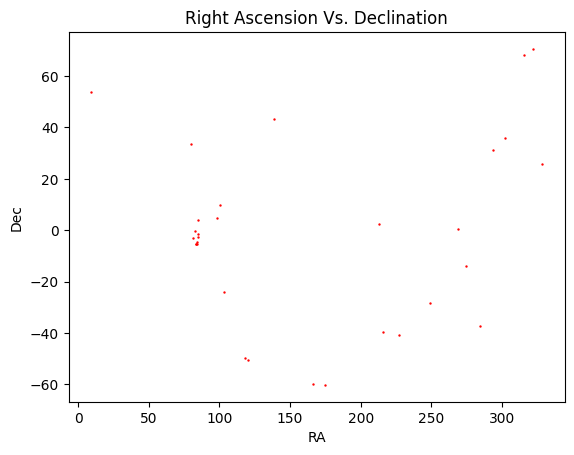

In [12]:
mphot.ra_vs_dec(df)

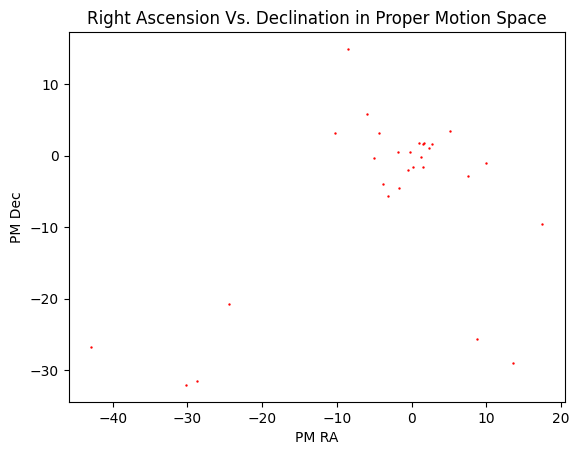

In [13]:
mphot.pmra_vs_pmdec(df)

In [2]:
source_ids = (
    4146594906281066368, 418001477279154304, 181233674136088960,
    3211026372078082048, 3220757015623151616, 3017360348171372672,
    3209634905754969856, 3017364063330718080, 3017367396223983616,
    3216486478101981056, 3224479171721217280, 3217413606922372992,
    3326710010525962624, 2922367976673391232, 5517239366958299776,
    5513811055342280448, 817013387993056640, 5338490937045044096,
    5336220823491735680, 3667302325846472320, 6116497702589633152,
    6005290206037557760, 6044420729667868928, 4371780385208211584,
    6730764715540788352, 2032810465079954944, 2059130368252069888,
    2270245431209611776, 2272185759996420992, 1796736625538995072,
    3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
       pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
       phot_rp_mean_mag, 
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

NameError: name 'query_by_adql' is not defined

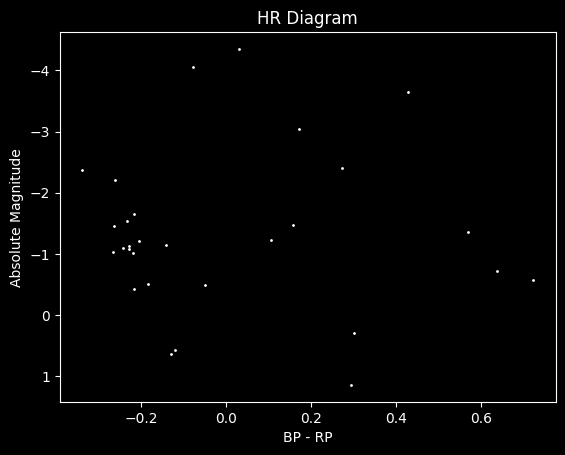

31


In [9]:
def get_distance(parallax):
    """Convert parallax (mas) to distance (pc)

    Args:
        parallax (float): Parallax in milliarcseconds

    Returns:
        float: Distance in parsecs
    """
    return 1 / (parallax / 1000)


def get_magnitude(phot_g_mean_mag, distance):
    """Convert apparent magnitude to absolute magnitude

    Args:
        phot_g_mean_mag (float): G-band apparent magnitude
        distance (float): Distance in parsecs

    Returns:
        float: Absolute magnitude
    """
    return phot_g_mean_mag - 5 * np.log10(distance / 10)


def get_bprp(phot_bp_mean_mag, phot_rp_mean_mag):
    """Calculate BP-RP colour index

    Args:
        phot_bp_mean_mag (float): BP-band apparent magnitude
        phot_rp_mean_mag (float): RP-band apparent magnitude

    Returns:
        float: BP-RP colour index
    """
    return phot_bp_mean_mag - phot_rp_mean_mag


def plot_hr_diagram(df):
    """Plot an HR diagram from a Gaia dataframe.

    Args:
        df (pandas.dataframe): Gaia data containing parallax,
            phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag.
    """
    df = df.dropna(subset=["parallax", "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag"])

    magnitude = [get_magnitude(row["phot_g_mean_mag"], get_distance(row["parallax"])) for _, row in df.iterrows()]
    bprp = [get_bprp(row["phot_bp_mean_mag"], row["phot_rp_mean_mag"]) for _, row in df.iterrows()]

    plt.style.use("dark_background")
    plt.scatter(bprp, magnitude, c="white", s=1)
    plt.xlabel("BP - RP")
    plt.ylabel("Absolute Magnitude")
    plt.title("HR Diagram")
    plt.gca().invert_yaxis()
    plt.show()

plot_hr_diagram(df)
print(len(df))

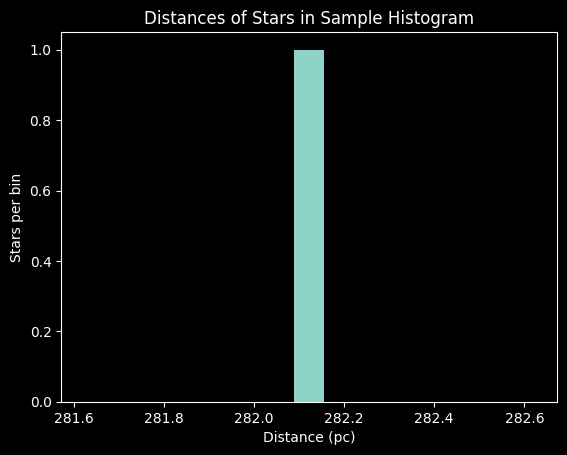

name: 282.1228795526555
Standard Deviation: nan


C:\Users\nakia\AppData\Local\Temp\ipykernel_10416\1506218769.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  fit = curve_fit(gaussian, x_1d_fit, y_1d_fit, p0 = [55, std, median])


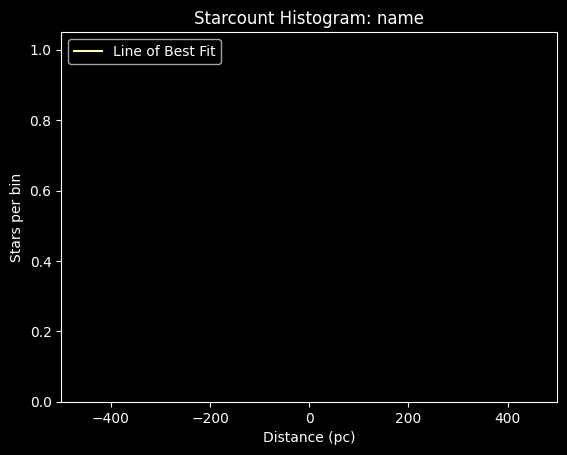

In [42]:
def hist(dists, bin_num, parallax=False):
    #Magnitude, Y-Values

    #Adjust if dist given in parallax
    if parallax:
        dists = (1000/parallax)

    plt.title("Distances of Stars in Sample Histogram")
    plt.hist(dists, bins=bin_num)

    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.show()

def gaussian(x, A, sigma, mu):
    return A*(1/(sigma * np.sqrt(2*np.pi)) * np.exp(-1*(x - mu)**2 / (2*sigma**2)))

def fittedHist(dists, bin_num=50, range=[-500,500],parallax=False):
    #Magnitude, Y-Values
    if parallax:
        dists = (1000/parallax)

    median = dists.median()
    std = dists.std()

    print("name"+": "+ str(median))
    plt.title("Starcount Histogram: "+ "name")

    h_1d_output = plt.hist(dists, bins=bin_num)
    x_plot = np.linspace(range[0],range[1], 300)
    x_1d_fit = (h_1d_output[1][:-1]+h_1d_output[1][1:])/2
    y_1d_fit = h_1d_output[0]
    fit = curve_fit(gaussian, x_1d_fit, y_1d_fit, p0 = [55, std, median])
    print("Standard Deviation: "+str(dists.std()))

    #Fix printing this
    #print(fit)
    plt.plot(x_plot, gaussian(x_plot, *fit[0]), label ='Line of Best Fit')

    plt.xlim(range[0], range[1])
    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.legend()
    plt.show()

dists = (1000/df["parallax"])
bin_num = 15
hist(dists, bin_num, parallax=False)
fittedHist(dists, bin_num, range=[-500,500],parallax=False)

In [28]:
#Now I will be testing the epoch photometry for one of the stars on the list: 4371780385208211584

source_id = (
 4371780385208211584
)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag, g_transit_mag, g_transit_time, 
bp_obs_time, rp_obs_time, bp_mag, rp_mag
FROM gaiadr3.gaia_source
WHERE source_id = {source_id}
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

HTTPError: Error 400: 
Cannot parse query '
SELECT  TOP 2000 source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag, g_transit_mag, g_transit_time, 
bp_obs_time, rp_obs_time, bp_mag, rp_mag
FROM gaiadr3.gaia_source
WHERE source_id = 4371780385208211584
' for job '9aa956f8-69a1-11f1-a354-bc97e148b76b-O': 6 unresolved identifiers: g_transit_mag [l.4 c.19 - l.4 c.32], g_transit_time [l.4 c.34 - l.4 c.48], bp_obs_time [l.5 c.1 - l.5 c.12], rp_obs_time [l.5 c.14 - l.5 c.25], bp_mag [l.5 c.27 - l.5 c.33], rp_mag [l.5 c.35 - l.5 c.41] !
 - Unknown column "g_transit_mag" !
 - Unknown column "g_transit_time" !
 - Unknown column "bp_obs_time" !
 - Unknown column "rp_obs_time" !
 - Unknown column "bp_mag" !
 - Unknown column "rp_mag" !


In [ ]:

def phase(t, T_0, P):
    """
    Compute the phase of time values relative to a reference epoch and period.

    Args:
        t (array-like): Time values.
        T_0 (float): Reference epoch, 't naught' (same units as 't').
        P (float): Period (same units as 't').

    Returns:
        numpy.ndarray: Phase values in the interval (0, 1).
    """
    return ((t-T_0)/P) % 1

#Plot G, Bp and Rp magnitude light curves in time.
def lightcurve(df:pd.DataFrame, title:str='Flux Vs. Time', overplot:bool=True, rejectflags: bool=False, period:float=None, xlims:tuple[int|float, int|float]=None, ylims:tuple[int|float, int|float]=None):
    """
    Plot G, Bp and Rp magnitude light curves in time.

    Args:
        df (pd.DataFrame): DataFrame containing photometry and time columns.
        title (str, optional): Plot title. Defaults to 'Flux Vs. Time'.
        overplot (bool, optional): If True, overplot all bands on a single axes. Defaults to True.
        rejectflags (bool, optional): If True, filter out rows flagged as rejected (uses
            'variability_flag_*_reject' columns). Defaults to False.
        period (float, optional): If provided, fold times on this period (phase plot). Defaults to None.
        xlims (tuple[float, float] or None, optional): X-axis limits. Defaults to None.
        ylims (tuple[float, float] or None, optional): Y-axis limits. Defaults to None.

    Raises:
        TypeError: If the input data is not a pandas DataFrame.
        KeyError: If the required columns are missing ('g_transit_mag', 'bp_mag', 'rp_mag', 'g_transit_time', 'bp_obs_time', 'rp_obs_time')

    Returns:
        None: Displays a matplotlib figure.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError('Data must be of type pandas.DataFrame')
    # Ensure required columns exist
    required_cols = {'g_transit_mag', 'bp_mag', 'rp_mag', 'g_transit_time', 'bp_obs_time', 'rp_obs_time'}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"DataFrame is missing required columns: {', '.join(sorted(missing))}")

    
    g = 'g_transit_mag'
    bp = 'bp_mag'
    rp = 'rp_mag'
    g_time = 'g_transit_time'
    bp_time = 'bp_obs_time'
    rp_time = 'rp_obs_time'

    # Filter Rejections if true
    if rejectflags:
        g_df = df[df['variability_flag_g_reject'] == False]
        bp_df = df[df['variability_flag_bp_reject'] == False]
        rp_df = df[df['variability_flag_rp_reject'] == False]
    else:
        g_df = df
        bp_df = df
        rp_df = df

    print(f"Len g, bp, and rp datasets respectively: {len(g_df)}, {len(bp_df)}, {len(rp_df)}")
    #X-Value: G Transit time
    x_g = g_df[g_time] + 2455197.5
    x_bp = bp_df[bp_time] + 2455197.5
    x_rp = rp_df[rp_time] + 2455197.5
    x_label = "Time (JD)"
    
    #Phase x if true
    if period is not None:
        x_g = phase(x_g, x_g.median(), period)
        x_bp = phase(x_bp, x_g.median(), period)
        x_rp = phase(x_rp, x_g.median(), period)
        x_label = f"Phase, p = {period}"
        print(f"P value: {period}")
    
    #Y-Value: Magnitudes for light band
    y_g = g_df[g] 
    y_bp = bp_df[bp]
    y_rp = rp_df[rp]

    if overplot is True:
        plt.xlabel(x_label)
        plt.ylabel("Band (app mag)")
        plt.scatter(x_g, y_g, c ='green', s = 3, label='G Band')
        plt.scatter(x_rp, y_rp, c ='red', s = 3, label='Rp Band')
        plt.scatter(x_bp, y_bp, c ='blue', s = 3, label='Bp Band')
        plt.title(title)
        plt.legend()
        plt.gca().invert_yaxis()
        if xlims is not None:
            plt.xlim(xlims[0], xlims[1])
        if ylims is not None:
            plt.ylim(ylims[0], ylims[1])
    else:
        fig, axes = plt.subplots(4, 1, figsize=(6, 10))
        # Plot on each subplot
        #axes[0].set_title(plot_title)
        axes[0].set_xlabel(x_label)
        axes[0].set_ylabel("G Band (app mag)")
        axes[0].scatter(x_g, y_g, c ='green', s = 4, label='G Band')
        axes[0].legend()
        axes[0].invert_yaxis()
    
        #axes[1].set_title(plot_title)
        axes[1].set_xlabel(x_label)
        axes[1].set_ylabel("Bp Band (app mag)")
        axes[1].scatter(x_bp, y_bp, c ='blue', s = 4, label='Bp Band')
        axes[1].legend()
        axes[1].invert_yaxis()
    
        #axes[2].set_title(plot_title)
        axes[2].set_xlabel(x_label)
        axes[2].set_ylabel("Rp Band (app mag)")
        axes[2].scatter(x_rp, y_rp, c ='red', s = 4, label='Rp Band')
        axes[2].legend()
        axes[2].invert_yaxis()

        #Overplot 
        #axes[2].set_title(plot_title)
        axes[3].set_xlabel(x_label)
        axes[3].set_ylabel("Band (app mag)")
        axes[3].scatter(x_g, y_g, c ='green', s = 3, label='G Band')
        axes[3].scatter(x_rp, y_rp, c ='red', s = 3, label='Rp Band')
        axes[3].scatter(x_bp, y_bp, c ='blue', s = 3, label='Bp Band')
        axes[3].legend()
        axes[3].invert_yaxis()

        if ylims is not None:
            for ax in axes: 
                #Flipped because the yaxis is inverted.
                ax.set_ylim(ylims[1], ylims[0])
        if xlims is not None:
            for ax in axes: 
                ax.set_ylim(xlims[0], xlims[1])

    plt.tight_layout()
    plt.show()